# Predicting annihilation probability over position

1. Loadings

In [1]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 989.5/989.5 kB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.5/692.5 kB 36.4 MB/s eta 0:00:00


In [2]:
%pip install awkward_pandas

In [14]:

import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Flatten,
    Concatenate
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:

ROOT_FILE = "new3merged.root"

file = uproot.open(ROOT_FILE)

print(file.keys())

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']


2. Branches for Three gamma NCS

In [5]:
branches = [

    "RunID",
    "EventID",

    "GammaIndex",

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

              RunID  EventID  GammaIndex       X_mm       Y_mm       Z_mm  \
0  slurm_35882963_1        0           0  42.213463 -29.997831 -44.219231   
1  slurm_35882963_1        0           1 -39.140385  43.925343  13.321461   
2  slurm_35882963_1        0           2  24.441950 -43.796162   5.251225   
3  slurm_35882963_1       14           0  25.520941  44.251762   1.901691   
4  slurm_35882963_1       14           1  50.743858  24.093874 -56.104988   

   EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  \
0         382.314117     382.314117             0.0     4.632441    -1.534016   
1         481.058167     481.058167             0.0     4.632441    -1.534016   
2         158.625549     158.625549             0.0     4.632441    -1.534016   
3         214.394302     214.394302             0.0     0.514280     0.849866   
4         334.142273     334.142273             0.0     0.514280     0.849866   

   AnnihilZ_mm  
0   -10.633850  
1   -10.633850  

In [6]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(xmin, xmax)
print(ymin, ymax)
print(zmin, zmax)

-97.96681213378906 98.7254638671875
-96.54037475585938 98.2959213256836
-99.81287384033203 98.93370056152344


In [10]:

images = []
targets = []
plane_features = []

event_groups = df.groupby(["RunID", "EventID"], sort=False)



print(f"Building images from {event_groups.ngroups} events...")


for i, ((run_id, event_id), event) in enumerate(event_groups):

   #defining vector plane
    points = event.sort_values("GammaIndex")[["X_mm", "Y_mm", "Z_mm"]].values

    if len(points) != 3:
        continue

    P1 = points[0]
    P2 = points[1]
    P3 = points[2]

    # two vectors in the plane
    v1 = P2 - P1
    v2 = P3 - P1

    # plane normal
    normal = np.cross(v1, v2)

    # normalise and store
    if np.linalg.norm(normal) == 0:
        continue

    normal = normal / np.linalg.norm(normal)
    plane_features.append(normal)

    # plane equation
    A, B, C = normal
    D = -np.dot(normal, P1)



    # all hits with this RunID and EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # Channel 0: XY projection

    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H_xy



    # Channel 1: XZ projection

    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz



    # Channel 2: YZ projection

    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz

    # Regression Targets


    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]



    # Store image and target


    images.append(image)
    targets.append(target)
    #plane_features.append(normal)

    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)
plane_features = np.array(plane_features, dtype=np.float32)

print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)
print("Plane features shape:", plane_features.shape)


Building images from 23684 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed
19000 events processed
20000 events processed
21000 events processed
22000 events processed
23000 events processed

Images shape : (23684, 64, 64, 3)
Targets shape: (23684, 3)
Plane features shape: (23684, 3)


Image normalisation

In [11]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


train test split

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, plane_train, plane_test, y_train, y_test = train_test_split(
    images,
    plane_features,
    targets,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


print("Training images :", x_train.shape)
print("Training planes :", plane_train.shape)
print("Training targets:", y_train.shape)

print("Test images :", x_test.shape)
print("Test planes :", plane_test.shape)
print("Test targets:", y_test.shape)

Training images : (18947, 64, 64, 3)
Training planes : (18947, 3)
Training targets: (18947, 3)
Test images : (4737, 64, 64, 3)
Test planes : (4737, 3)
Test targets: (4737, 3)


scaler

In [13]:
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)


print(y_train_scaled[0])

[-1.5680906   1.4992275   0.80531687]


building cnn

In [39]:
# Image input

image_input = Input(
    shape=(64,64,3),
    name="detector_image"
)


# First convolution block

x = Conv2D(
    16,
    (3,3),
    activation="relu"
)(image_input)

x = MaxPooling2D()(x)



# Second convolution block

x = Conv2D(
    32,
    (3,3),
    activation="relu"
)(x)

x = MaxPooling2D()(x)



# Third convolution block

x = Conv2D(
    64,
    (3,3),
    activation="relu"
)(x)

x = MaxPooling2D()(x)



# Convert feature maps into vector

x = Flatten()(x)

# Plane input

plane_input = Input(
    shape=(3,),
    name="plane_normal"
)


plane_features = Dense(
    16,
    activation="relu"
)(plane_input)

#Combining CNN and plane info
combined = Concatenate()(
    [x, plane_features]
)

#fully connected layers
combined = Dense(
    128,
    activation="relu"
)(combined)


combined = Dropout(0.3)(combined)
raw_output = Dense(6)(combined)

mu = raw_output[:, :3]

sigma = raw_output[:, 3:]

sigma = tf.keras.layers.Activation(
    "softplus"
)(sigma)

output = tf.keras.layers.Concatenate()(
    [mu, sigma]
)



In [40]:
model = Model(
    inputs=[
        image_input,
        plane_input
    ],
    outputs=output
)

In [41]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ detector_image      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 62, 62,    │        448 │ detector_image[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 31, 31,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 6, 6, 64)  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_normal        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2304)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │         64 │ plane_normal[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2320)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │    297,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 6)         │        774 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 3)         │          0 │ dense_4[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 3)         │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3)         │          0 │ get_item_1[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 6)         │          0 │ get_item[0][0],   │
│ (Concatenate)       │                   │            │ activation[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,510 (1.23 MB)

 Trainable params: 321,510 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

defining probabilotic loss functions

In [42]:
def gaussian_nll(y_true, y_pred):

    # Split predictions into mean and uncertainty

    mu = y_pred[:, :3]      # predicted x,y,z
    sigma = y_pred[:, 3:]   # predicted uncertainty


    # Prevent sigma becoming negative or zero
    sigma = tf.nn.softplus(sigma) + 1e-6


    # Gaussian negative log likelihood
    loss = (
        0.5 * tf.square((y_true - mu) / sigma)
        + tf.math.log(sigma)
    )


    # Average over x,y,z
    return tf.reduce_mean(loss)

compiling model

In [43]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=gaussian_nll
)

training model

In [44]:
history = model.fit(
    [
        x_train,
        plane_train
    ],
    y_train_scaled,
    validation_data=(
        [
            x_test,
            plane_test
        ],
        y_test_scaled
    ),
    epochs=50,
    batch_size=32
)

Epoch 1/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.4922 - val_loss: 0.4694
Epoch 2/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4403 - val_loss: 0.4265
Epoch 3/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4135 - val_loss: 0.4059
Epoch 4/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4014 - val_loss: 0.3940
Epoch 5/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3937 - val_loss: 0.3813
Epoch 6/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3838 - val_loss: 0.3804
Epoch 7/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3775 - val_loss: 0.3700
Epoch 8/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3704 - val_loss: 0.3640
Epoch 9/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3635 - val_loss: 0.3562
Epoch 10/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3564 - val_loss: 0.3541
Epoch 11/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3493 - val_loss: 0.3381
Epoch 12/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/st

plotting loss

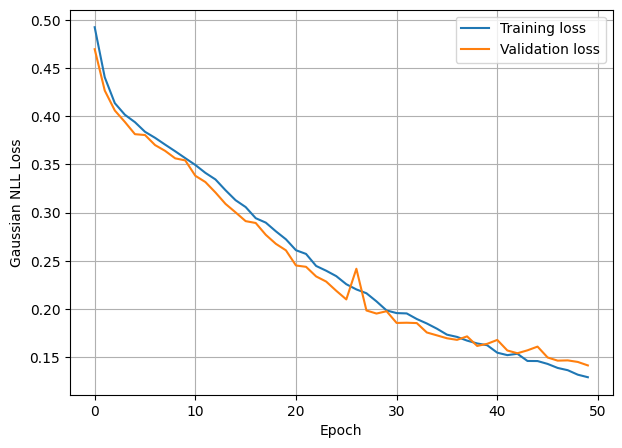

In [45]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Gaussian NLL Loss")
plt.legend()
plt.grid()
plt.show()

making predictions

In [46]:
prediction = model.predict(
    [
        x_test,
        plane_test
    ]
)
print(prediction.shape)

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
(4737, 6)


In [47]:
mu_scaled = prediction[:, :3]
sigma_scaled = prediction[:, 3:]

converting back to mm

In [48]:
mu_mm = target_scaler.inverse_transform(
    mu_scaled
)

In [49]:
sigma_mm = sigma_scaled * target_scaler.scale_

checking pred

In [50]:
for i in range(5):

    print("Event", i)

    print(
        "True:",
        y_test[i]
    )

    print(
        "Predicted:",
        mu_mm[i]
    )

    print(
        "Uncertainty:",
        sigma_mm[i]
    )

    print()

Event 0
True: [-0.47320542  4.2953987  -7.0890417 ]
Predicted: [ 0.45760295  2.9830647  -7.022494  ]
Uncertainty: [0.03153044 0.10377824 0.00379489]

Event 1
True: [-1.8619603  4.479793  -6.924948 ]
Predicted: [ 1.8790475  2.6284273 -8.018509 ]
Uncertainty: [0.4370986  0.01758025 0.06264513]

Event 2
True: [ 2.2345228  1.8696158 -8.54246  ]
Predicted: [ 1.5687153  2.2217774 -8.404049 ]
Uncertainty: [0.02731816 0.00848283 0.32951425]

Event 3
True: [ 1.3888016   0.11342431 -6.7022667 ]
Predicted: [ 0.4861749  2.904229  -6.822211 ]
Uncertainty: [0.11146632 1.10851791 0.08317206]

Event 4
True: [ 3.8511534  2.3501887 -9.376963 ]
Predicted: [ 2.3030376  3.5158257 -8.294421 ]
Uncertainty: [0.13466362 0.19209607 0.36165811]



calculating position error and MAE

In [51]:
position_error = mu_mm - y_test


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 2.4165907 mm


In [52]:
from sklearn.metrics import mean_absolute_error


mae_x = mean_absolute_error(
    y_test[:,0],
    mu_mm[:,0]
)

mae_y = mean_absolute_error(
    y_test[:,1],
    mu_mm[:,1]
)

mae_z = mean_absolute_error(
    y_test[:,2],
    mu_mm[:,2]
)


print("X MAE:", mae_x, "mm")
print("Y MAE:", mae_y, "mm")
print("Z MAE:", mae_z, "mm")

X MAE: 1.1225299835205078 mm
Y MAE: 1.4228674173355103 mm
Z MAE: 1.0502668619155884 mm


In [53]:
average_uncertainty = np.mean(
    sigma_mm,
    axis=1
)


correlation = np.corrcoef(
    average_uncertainty,
    distance_error
)[0,1]


print(
    "Uncertainty-error correlation:",
    correlation
)

Uncertainty-error correlation: 0.2488706242651054


plot reconstuction

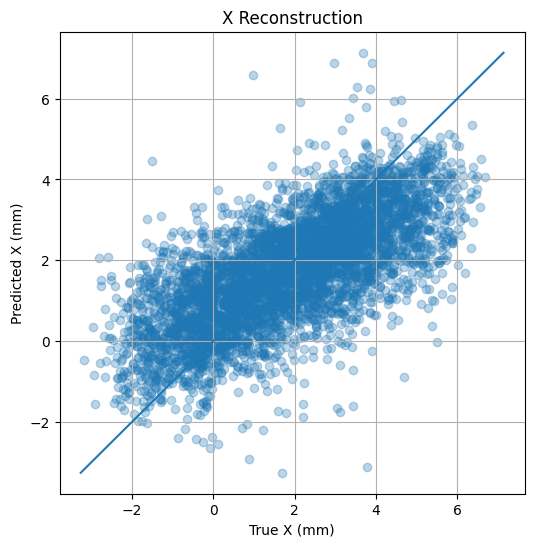

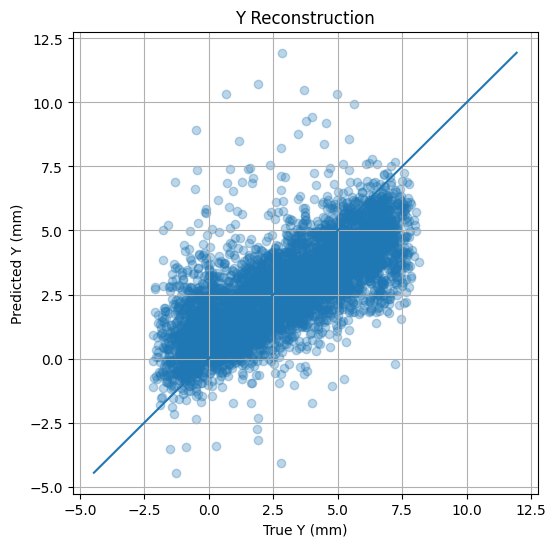

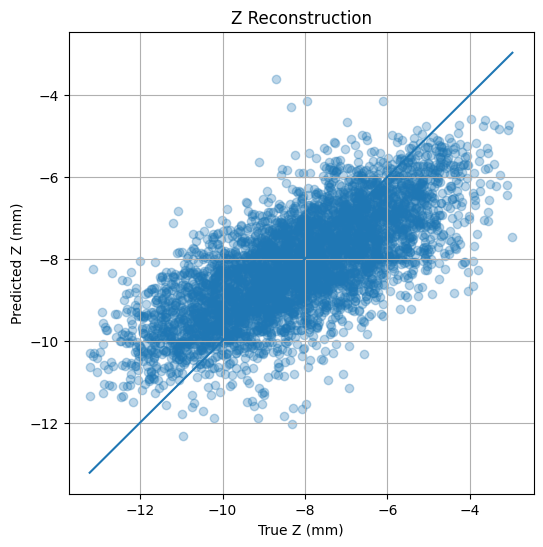

In [54]:
import matplotlib.pyplot as plt


coordinates = ["X", "Y", "Z"]


for i, coord in enumerate(coordinates):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_test[:,i],
        mu_mm[:,i],
        alpha=0.3
    )

    # perfect prediction line
    minimum = min(
        y_test[:,i].min(),
        mu_mm[:,i].min()
    )

    maximum = max(
        y_test[:,i].max(),
        mu_mm[:,i].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum]
    )

    plt.xlabel(f"True {coord} (mm)")
    plt.ylabel(f"Predicted {coord} (mm)")
    plt.title(f"{coord} Reconstruction")

    plt.grid()
    plt.show()

residuals

In [55]:
residuals = mu_mm - y_test

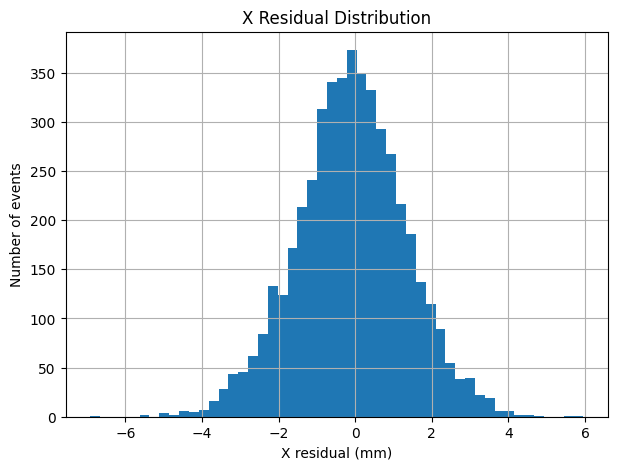

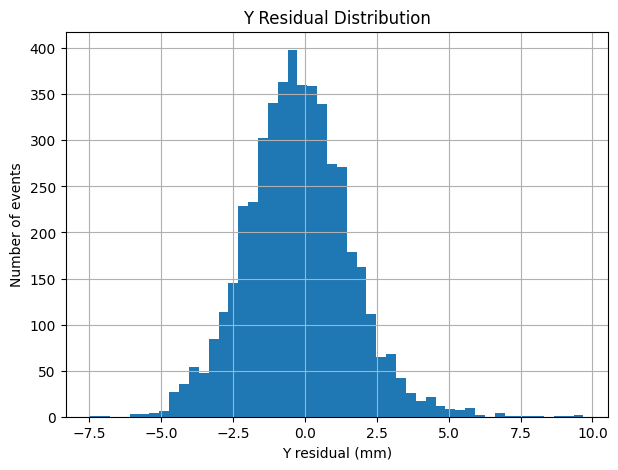

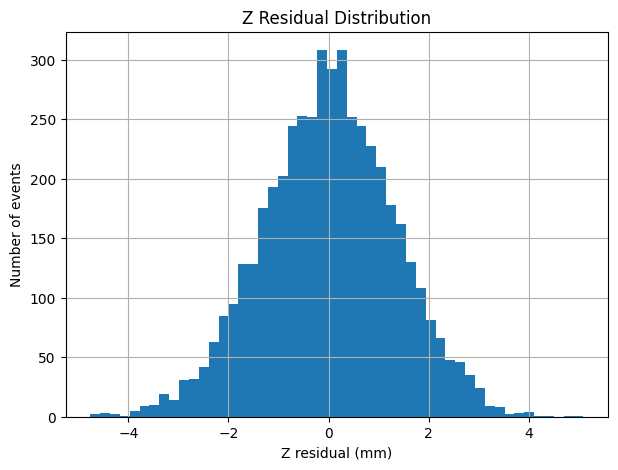

In [56]:
for i, coord in enumerate(coordinates):

    plt.figure(figsize=(7,5))

    plt.hist(
        residuals[:,i],
        bins=50
    )

    plt.xlabel(
        f"{coord} residual (mm)"
    )

    plt.ylabel(
        "Number of events"
    )

    plt.title(
        f"{coord} Residual Distribution"
    )

    plt.grid()
    plt.show()

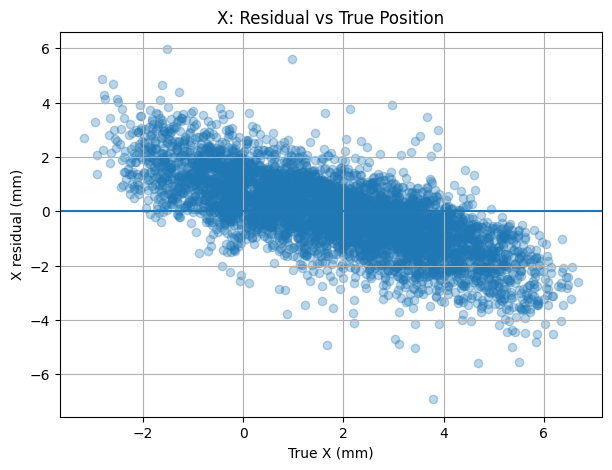

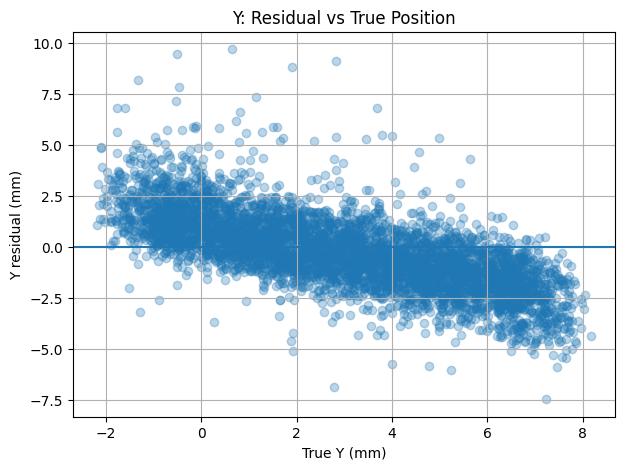

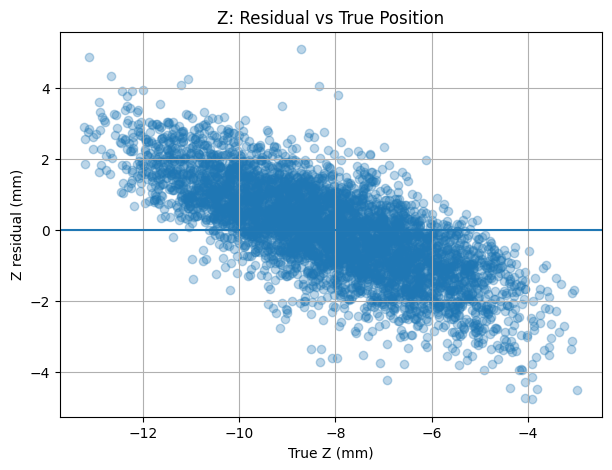

In [57]:
for i, coord in enumerate(coordinates):

    plt.figure(figsize=(7,5))

    plt.scatter(
        y_test[:,i],
        residuals[:,i],
        alpha=0.3
    )

    plt.axhline(
        0
    )

    plt.xlabel(
        f"True {coord} (mm)"
    )

    plt.ylabel(
        f"{coord} residual (mm)"
    )

    plt.title(
        f"{coord}: Residual vs True Position"
    )

    plt.grid()
    plt.show()

uncenrtainity vs erorr

In [58]:
mean_sigma = np.mean(
    sigma_mm,
    axis=1
)

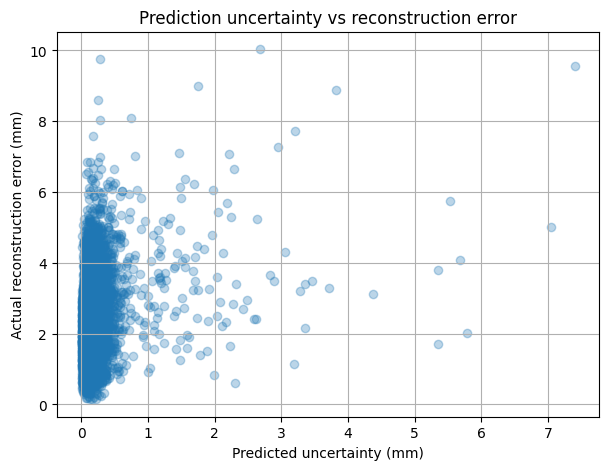

In [59]:
plt.figure(figsize=(7,5))

plt.scatter(
    mean_sigma,
    distance_error,
    alpha=0.3
)

plt.xlabel(
    "Predicted uncertainty (mm)"
)

plt.ylabel(
    "Actual reconstruction error (mm)"
)

plt.title(
    "Prediction uncertainty vs reconstruction error"
)

plt.grid()
plt.show()

In [60]:
print(
    "Mean 3D position error:",
    np.mean(distance_error),
    "mm"
)


print(
    "Median 3D position error:",
    np.median(distance_error),
    "mm"
)


print(
    "Mean uncertainty:",
    np.mean(mean_sigma),
    "mm"
)

Mean 3D position error: 2.4165907 mm
Median 3D position error: 2.244796 mm
Mean uncertainty: 0.21217540238724553 mm


In [61]:
for i in range(5):

    print("Event", i)

    print("Error:",
          distance_error[i],
          "mm")

    print("Uncertainty:",
          sigma_mm[i])

    print()

Event 0
Error: 1.6102961 mm
Uncertainty: [0.03153044 0.10377824 0.00379489]

Event 1
Error: 4.3149242 mm
Uncertainty: [0.4370986  0.01758025 0.06264513]

Event 2
Error: 0.7658167 mm
Uncertainty: [0.02731816 0.00848283 0.32951425]

Event 3
Error: 2.9355938 mm
Uncertainty: [0.11146632 1.10851791 0.08317206]

Event 4
Error: 2.219745 mm
Uncertainty: [0.13466362 0.19209607 0.36165811]



In [62]:
mean_sigma = np.mean(
    sigma_mm,
    axis=1
)

correlation = np.corrcoef(
    mean_sigma,
    distance_error
)[0,1]

print(
    "Uncertainty-error correlation:",
    correlation
)

Uncertainty-error correlation: 0.2488706242651054
